# VGG16-GA-XGBoost

In [1]:
import os
import cv2
import time
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import plotly.graph_objects as go
import plotly.express as px
import plotly.figure_factory as ff
import pydicom
from pydicom.pixel_data_handlers.util import apply_voi_lut
from collections import Counter

In [2]:
import os
import tensorflow as tf
BASE_DIR = "/kaggle/input/datasets/tonytoanpham/datamri"
train_dir = os.path.join(BASE_DIR, "Training")
test_dir  = os.path.join(BASE_DIR, "Testing")
print("Train path:", train_dir)
print("Test path:", test_dir)
# ========================
# 2. Parameters
# ========================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
# ========================
# 3. Load datasets
# ========================
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical")
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical")
# ========================
# 4. Improve performance (cache + prefetch)
# ========================
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)
# ========================
# 5. Data Augmentation
# ========================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])
# Example: apply augmentation
for images, labels in train_ds.take(1):
    augmented = data_augmentation(images)

Train path: /kaggle/input/datasets/tonytoanpham/datamri/Training
Test path: /kaggle/input/datasets/tonytoanpham/datamri/Testing
Found 5712 files belonging to 4 classes.


I0000 00:00:1784740379.776669      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784740379.779420      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1311 files belonging to 4 classes.


   class_name  count
0   pituitary   1457
1     notumor   1595
2  meningioma   1339
3      glioma   1321


/tmp/ipykernel_58/874787560.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="class_name", y="count", palette="viridis")


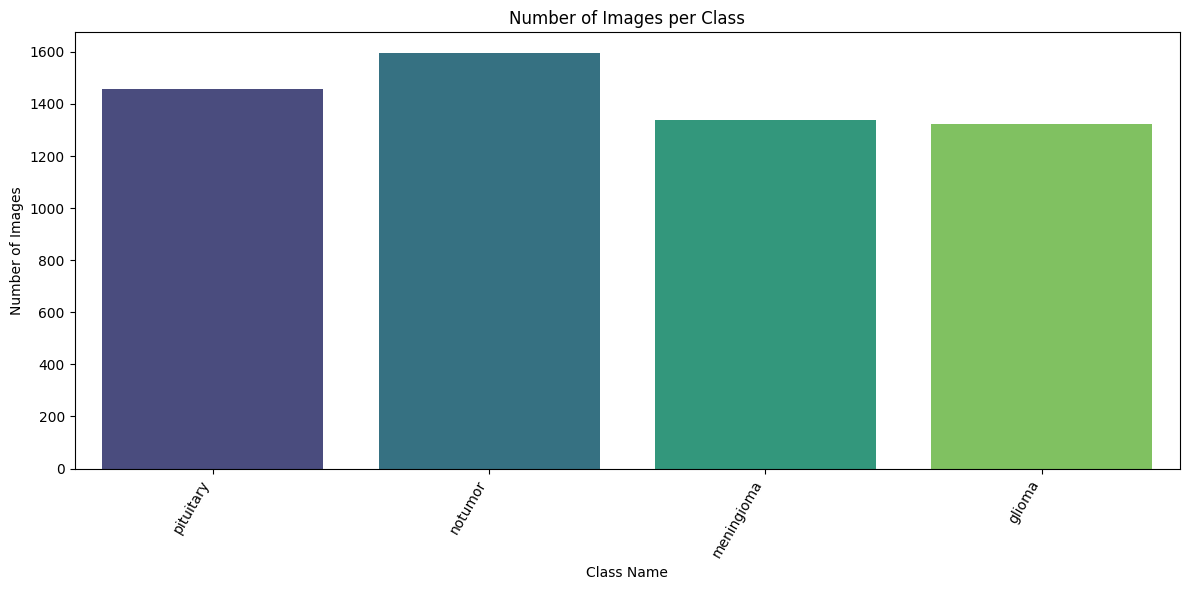

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import tensorflow as tf

# Get class names
class_names = os.listdir(train_dir)
data_list = []

# Count the number of images in each class
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        data_list.append({
            "class_name": class_name,
            "count": count
        })

# Create a DataFrame
df = pd.DataFrame(data_list)
print(df)

# ========================
# Plot using Seaborn
# ========================
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="class_name", y="count", palette="viridis")

plt.xticks(rotation=60, ha="right")
plt.title("Number of Images per Class")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

# ========================
# Interactive Plot using Plotly
# ========================
fig = px.bar(
    df,
    x="class_name",
    y="count",
    title="Number of Images per Class",
    text="count"
)

fig.update_traces(textposition="outside")
fig.update_layout(
    xaxis_title="Class Name",
    yaxis_title="Number of Images",
    xaxis_tickangle=-45
)

fig.show()

In [4]:
import os
import pandas as pd

# --- Function to count images per class ---
def get_class_counts(base_dir):
    data_list = []
    class_names = os.listdir(base_dir)
    for class_name in class_names:
        class_path = os.path.join(base_dir, class_name)
        if os.path.isdir(class_path):
            count = len(os.listdir(class_path))
            data_list.append({"class_name": class_name, "count": count})
    return pd.DataFrame(data_list)

# --- Paths ---
BASE_DIR = "/kaggle/input/datasets/tonytoanpham/datamri"
train_dir = os.path.join(BASE_DIR, "Training")
test_dir  = os.path.join(BASE_DIR, "Testing")

# --- Count per dataset ---
train_df = get_class_counts(train_dir)
test_df  = get_class_counts(test_dir)

# --- Merge train + test ---
total_df = pd.merge(train_df, test_df, on="class_name", how="outer", suffixes=("_train", "_test")).fillna(0)
total_df["total"] = total_df["count_train"] + total_df["count_test"]

# --- Add grand total row ---
grand_total = total_df["total"].sum()
total_df = pd.concat([total_df, pd.DataFrame([{"class_name": "Total", "count_train": train_df["count"].sum(),
                                               "count_test": test_df["count"].sum(), "total": grand_total}])],
                     ignore_index=True)

print(total_df)



   class_name  count_train  count_test  total
0      glioma         1321         300   1621
1  meningioma         1339         306   1645
2     notumor         1595         405   2000
3   pituitary         1457         300   1757
4       Total         5712        1311   7023


In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.applications import VGG16

# ========================
# 1. Load dataset
# ========================
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode="categorical"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(224, 224),
    batch_size=32,
    label_mode="categorical"
)

# ✅ Save class names BEFORE caching
class_names = train_ds.class_names
num_classes = len(class_names)



Found 5712 files belonging to 4 classes.
Found 1311 files belonging to 4 classes.


# * Grad-CAM Method for VGG16

Train path: /kaggle/input/datasets/tonytoanpham/datamri/Training
Test path : /kaggle/input/datasets/tonytoanpham/datamri/Testing
Categories: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train images: 5712
Test images : 1311
Using device: cuda
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 188MB/s] 


Using 2 GPUs for feature extraction


Extracting features: 100%|██████████| 1311/1311 [00:19<00:00, 65.71it/s]
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning:

Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.



Train feature shape: (5712, 512)
Test feature shape : (1311, 512)
GaussianNB Test Accuracy: 0.7780320366132724

Showing Grad-CAM for some test images...

[1/5] /kaggle/input/datasets/tonytoanpham/datamri/Testing/glioma/Te-gl_0066.jpg


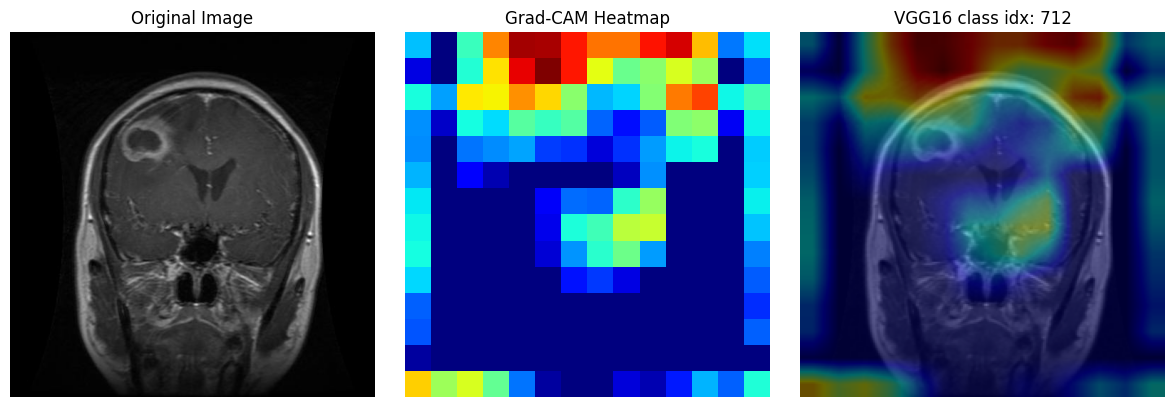

[2/5] /kaggle/input/datasets/tonytoanpham/datamri/Testing/glioma/Te-gl_0043.jpg


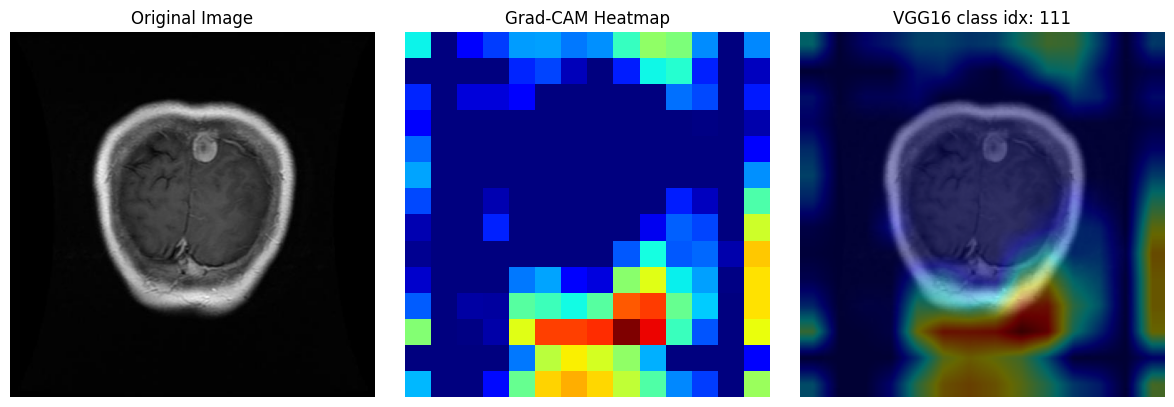

[3/5] /kaggle/input/datasets/tonytoanpham/datamri/Testing/glioma/Te-gl_0166.jpg


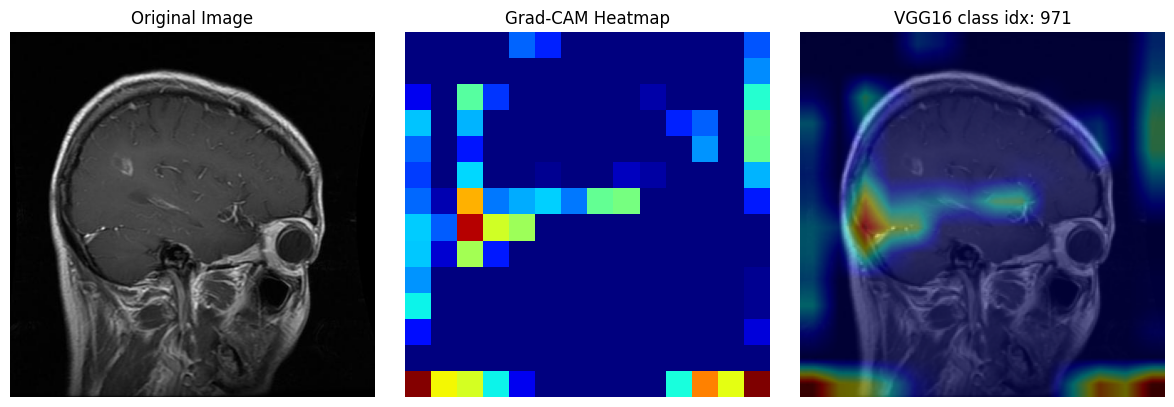

[4/5] /kaggle/input/datasets/tonytoanpham/datamri/Testing/glioma/Te-gl_0048.jpg


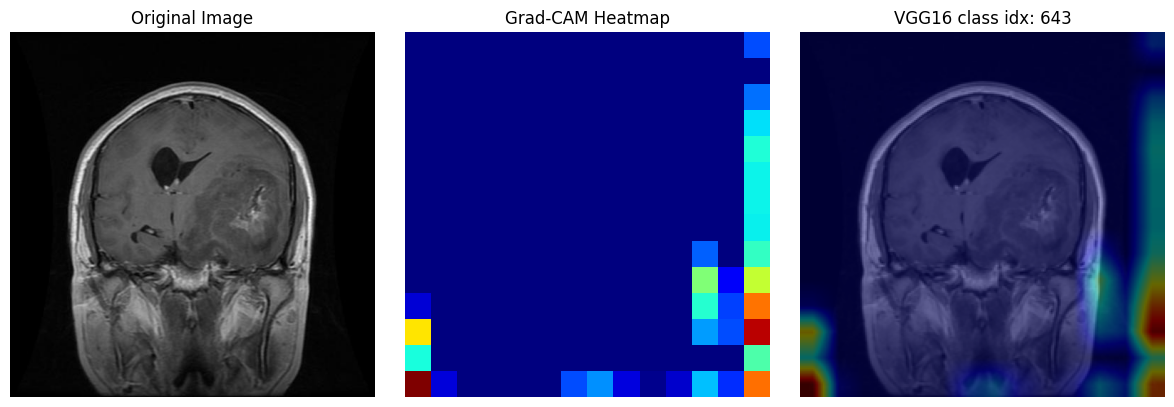

[5/5] /kaggle/input/datasets/tonytoanpham/datamri/Testing/glioma/Te-gl_0028.jpg


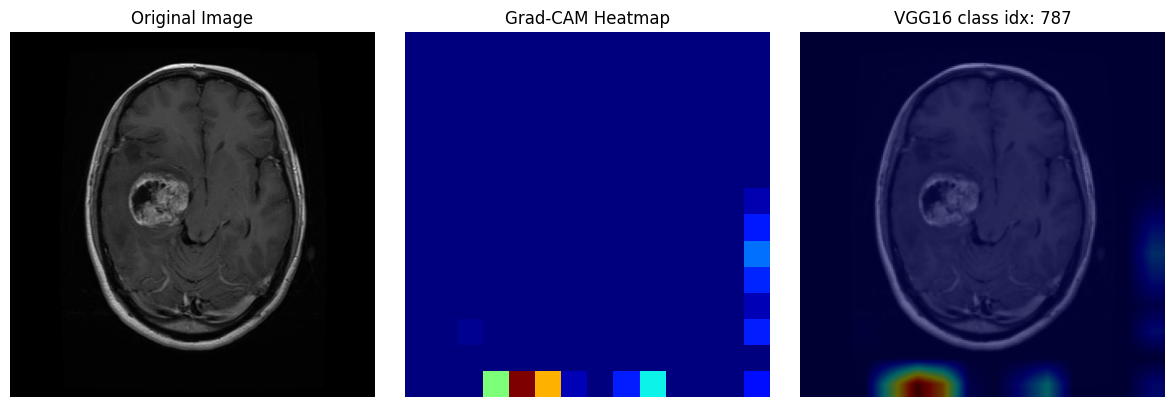

Saved Grad-CAM images to: ./gradcam_outputs
Total Time: 110.71457576751709


In [7]:
import os
import time
import cv2
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

st = time.time()

# =========================
# Step 1: Setup paths
# =========================
BASE_DIR = "/kaggle/input/datasets/tonytoanpham/datamri"
train_dir = os.path.join(BASE_DIR, "Training")
test_dir  = os.path.join(BASE_DIR, "Testing")

print("Train path:", train_dir)
print("Test path :", test_dir)

categories = sorted(
    [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
)
print("Categories:", categories)

# Train paths + labels
train_paths, y_train = [], []
for idx, category in enumerate(categories):
    cat_path = os.path.join(train_dir, category)
    for filename in os.listdir(cat_path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            train_paths.append(os.path.join(cat_path, filename))
            y_train.append(idx)

# Test paths + labels
test_paths, y_test = [], []
for idx, category in enumerate(categories):
    cat_path = os.path.join(test_dir, category)
    for filename in os.listdir(cat_path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            test_paths.append(os.path.join(cat_path, filename))
            y_test.append(idx)

print(f"Train images: {len(train_paths)}")
print(f"Test images : {len(test_paths)}")

# =========================
# Step 2: Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# Step 3: Helper - disable inplace ReLU
# =========================
def disable_inplace_relu(model):
    for module in model.modules():
        if isinstance(module, nn.ReLU):
            module.inplace = False

# =========================
# Step 4: Load models
# =========================
# 4.1 Model for Grad-CAM
vgg_cam = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
disable_inplace_relu(vgg_cam)
vgg_cam = vgg_cam.to(device)
vgg_cam.eval()

# 4.2 Model for feature extraction
vgg_feat = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
disable_inplace_relu(vgg_feat)
vgg_feat.classifier = nn.Identity()
vgg_feat.avgpool = nn.AdaptiveAvgPool2d((1, 1))
vgg_feat = vgg_feat.to(device)
vgg_feat.eval()

# DataParallel only for feature extraction if multiple GPUs
if torch.cuda.device_count() > 1:
    print("Using", torch.cuda.device_count(), "GPUs for feature extraction")
    vgg_feat = nn.DataParallel(vgg_feat)

# =========================
# Step 5: Transform
# =========================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

# =========================
# Step 6: Feature extraction
# =========================
def extract_features(image_paths, model):
    features = []
    valid_paths = []

    for path in tqdm(image_paths, desc="Extracting features"):
        try:
            img = Image.open(path).convert("RGB")
            img_tensor = transform(img).unsqueeze(0).to(device)

            with torch.no_grad():
                feat = model(img_tensor).view(-1).cpu().numpy()

            features.append(feat)
            valid_paths.append(path)

        except Exception as e:
            print(f"Error processing {path}: {e}")

    return np.array(features), valid_paths

features_train, valid_train_paths = extract_features(train_paths, vgg_feat)
features_test, valid_test_paths = extract_features(test_paths, vgg_feat)

# Nếu có ảnh lỗi, đồng bộ lại label
if len(valid_train_paths) != len(train_paths):
    valid_train_set = set(valid_train_paths)
    y_train = [y for p, y in zip(train_paths, y_train) if p in valid_train_set]

if len(valid_test_paths) != len(test_paths):
    valid_test_set = set(valid_test_paths)
    y_test = [y for p, y in zip(test_paths, y_test) if p in valid_test_set]

print("Train feature shape:", features_train.shape)
print("Test feature shape :", features_test.shape)

# =========================
# Step 7: Train GaussianNB
# =========================
clf = GaussianNB()
clf.fit(features_train, y_train)

y_pred = clf.predict(features_test)
acc = accuracy_score(y_test, y_pred)
print("GaussianNB Test Accuracy:", acc)

# =========================
# Step 8: Grad-CAM
# =========================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.forward_handle = None
        self.backward_handle = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.forward_handle = self.target_layer.register_forward_hook(forward_hook)
        self.backward_handle = self.target_layer.register_backward_hook(backward_hook)

    def remove_hooks(self):
        if self.forward_handle is not None:
            self.forward_handle.remove()
        if self.backward_handle is not None:
            self.backward_handle.remove()

    def generate(self, input_tensor, class_idx=None):
        # clone to avoid autograd/view issues
        input_tensor = input_tensor.clone().detach().to(device)
        input_tensor.requires_grad_(True)

        self.model.zero_grad()

        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        score = output[:, class_idx]
        score.backward(retain_graph=False)

        gradients = self.gradients[0]    # [C, H, W]
        activations = self.activations[0]  # [C, H, W]

        weights = gradients.mean(dim=(1, 2))  # [C]

        cam = torch.zeros(activations.shape[1:], dtype=torch.float32, device=activations.device)
        for i, w in enumerate(weights):
            cam += w * activations[i]

        cam = torch.relu(cam)
        cam -= cam.min()
        cam /= (cam.max() + 1e-8)

        return cam.cpu().numpy(), class_idx

# VGG16 last conv layer
target_layer = vgg_cam.features[28]
grad_cam = GradCAM(vgg_cam, target_layer)

# =========================
# Step 9: Utility functions
# =========================
def denormalize_image(tensor):
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)

    img = tensor.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img

def overlay_heatmap(img_np, cam, alpha=0.4):
    heatmap = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    img_uint8 = np.uint8(img_np * 255.0)
    overlay = cv2.addWeighted(img_uint8, 1 - alpha, heatmap, alpha, 0)
    return overlay

def predict_with_gnb(image_path):
    img = Image.open(image_path).convert("RGB")
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        feat = vgg_feat(img_tensor).view(1, -1).cpu().numpy()

    pred_idx = clf.predict(feat)[0]
    return pred_idx

def show_gradcam(image_path, class_names=None, use_vgg_prediction=True):
    img = Image.open(image_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)

    if use_vgg_prediction:
        cam, pred_class = grad_cam.generate(input_tensor, class_idx=None)
        title_pred = f"VGG16 class idx: {pred_class}"
    else:
        # Nếu muốn ép Grad-CAM theo nhãn GaussianNB thì không hoàn toàn đúng về mặt mô hình,
        # nhưng có thể map theo predicted class index của GNB nếu số class phù hợp
        gnb_pred = predict_with_gnb(image_path)
        cam, pred_class = grad_cam.generate(input_tensor, class_idx=gnb_pred)
        if class_names is not None:
            title_pred = f"GNB pred: {class_names[gnb_pred]}"
        else:
            title_pred = f"GNB pred idx: {gnb_pred}"

    img_np = denormalize_image(input_tensor[0])
    overlay = overlay_heatmap(img_np, cam)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cam, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(title_pred)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

def save_gradcam(image_path, save_path, class_names=None, use_vgg_prediction=True):
    img = Image.open(image_path).convert("RGB")
    input_tensor = transform(img).unsqueeze(0).to(device)

    if use_vgg_prediction:
        cam, pred_class = grad_cam.generate(input_tensor, class_idx=None)
        pred_text = str(pred_class)
    else:
        gnb_pred = predict_with_gnb(image_path)
        cam, pred_class = grad_cam.generate(input_tensor, class_idx=gnb_pred)
        pred_text = class_names[gnb_pred] if class_names is not None else str(gnb_pred)

    img_np = denormalize_image(input_tensor[0])
    overlay = overlay_heatmap(img_np, cam)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cam, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(f"Prediction: {pred_text}")
    plt.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()

# =========================
# Step 10: Demo vài ảnh test
# =========================
print("\nShowing Grad-CAM for some test images...\n")
num_show = min(5, len(valid_test_paths))
for i in range(num_show):
    print(f"[{i+1}/{num_show}] {valid_test_paths[i]}")
    show_gradcam(valid_test_paths[i], class_names=categories, use_vgg_prediction=True)

# =========================
# Step 11: Save Grad-CAM results
# =========================
output_dir = "./gradcam_outputs"
os.makedirs(output_dir, exist_ok=True)

num_save = min(10, len(valid_test_paths))
for i in range(num_save):
    image_path = valid_test_paths[i]
    filename = os.path.splitext(os.path.basename(image_path))[0]
    save_path = os.path.join(output_dir, f"{filename}_gradcam.png")
    save_gradcam(image_path, save_path, class_names=categories, use_vgg_prediction=True)

print(f"Saved Grad-CAM images to: {output_dir}")

# =========================
# Final time
# =========================
end = time.time()
print("Total Time:", end - st)

# cleanup hook if needed
grad_cam.remove_hooks()

# 2. VGG16-GA-XGBoost

In [8]:
import os
import numpy as np
from PIL import Image
from tqdm import tqdm
import time
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

st = time.time()

# --------- Step 1: Setup paths ---------
BASE_DIR = "/kaggle/input/datasets/tonytoanpham/datamri"
train_dir = os.path.join(BASE_DIR, "Training")
test_dir  = os.path.join(BASE_DIR, "Testing")

print("Train path:", train_dir)
print("Test path:", test_dir)

# Lấy class names từ thư mục
categories = sorted(os.listdir(train_dir))
print("Categories:", categories)

# Lấy danh sách ảnh và nhãn (train)
train_paths, y_train = [], []
for idx, category in enumerate(categories):
    cat_path = os.path.join(train_dir, category)
    for filename in os.listdir(cat_path):
        if filename.lower().endswith(('.jpg', '.png', '.jpeg')):
            train_paths.append(os.path.join(cat_path, filename))
            y_train.append(idx)

# Lấy danh sách ảnh và nhãn (test)
test_paths, y_test = [], []
for idx, category in enumerate(categories):
    cat_path = os.path.join(test_dir, category)
    for filename in os.listdir(cat_path):
        if filename.lower().endswith(('.jpg', '.png', '.jpeg')):
            test_paths.append(os.path.join(cat_path, filename))
            y_test.append(idx)

print(f"Train images: {len(train_paths)}, Test images: {len(test_paths)}")

# --------- Step 2: Load VGG16 ---------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

vgg = models.vgg16(pretrained=True)
vgg.classifier = nn.Identity()  # bỏ FC layer
vgg.avgpool = nn.AdaptiveAvgPool2d((1, 1))  # avg pool
vgg = vgg.to(device)
if torch.cuda.device_count() > 1:
    vgg = nn.DataParallel(vgg)
vgg.eval()

# --------- Step 3: Transform ---------
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])
# --------- Step 4: Feature extraction ---------
def extract_features(image_paths):
    features = []
    for path in tqdm(image_paths, desc="Extracting features"):
        try:
            img = Image.open(path).convert('RGB')
            img_tensor = transform(img).unsqueeze(0).to(device)
            with torch.no_grad():
                feat = vgg(img_tensor).view(-1).cpu().numpy()
            features.append(feat)
        except Exception as e:
            print(f"Error processing {path}: {e}")
    return np.array(features)

features_train = extract_features(train_paths)
features_test  = extract_features(test_paths)


end = time.time()
print("Total Time:", end - st)


Train path: /kaggle/input/datasets/tonytoanpham/datamri/Training
Test path: /kaggle/input/datasets/tonytoanpham/datamri/Testing
Categories: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train images: 5712, Test images: 1311
Using device: cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning:

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning:

Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.

Extracting features: 100%|██████████| 1311/1311 [00:15<00:00, 82.54it/s]

Total Time: 89.72883415222168


In [ ]:
# Lưu đặc trưng train và test
np.savez('features_MRIbrain.npz',
         features_train=features_train,
         features_test=features_test,
         y_train=np.array(y_train),
         y_test=np.array(y_test))
print("Save file features_MRIbrain.npz")

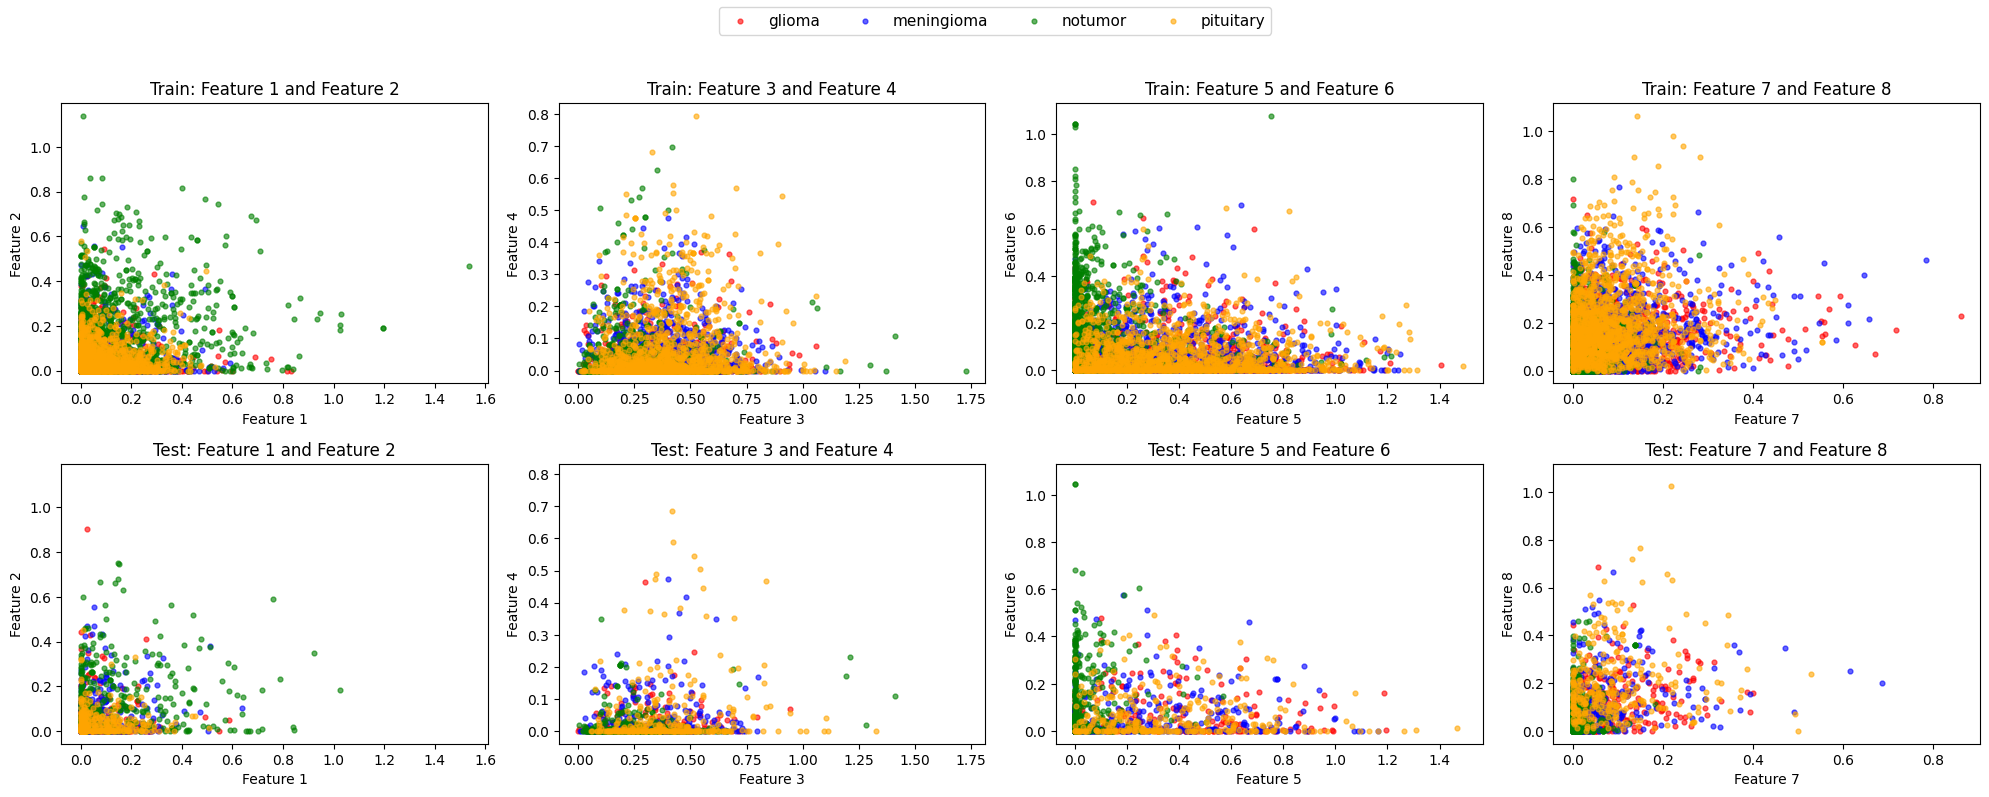

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Load dữ liệu
data = np.load('/kaggle/input/datasets/tonytoanpham/datafeaturesnew/features_MRIbrain.npz')
features_train = data['features_train']
features_test  = data['features_test']
y_train = data['y_train']
y_test  = data['y_test']

# Nhãn và màu
labels = ['glioma', 'meningioma', 'notumor', 'pituitary']
colors = ['red', 'blue', 'green', 'orange']

# 4 cặp đặc trưng
pairs = [(0, 1), (2, 3), (4, 5), (6, 7)]

# Tạo figure: 2 hàng × 4 cột
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for col, (f1, f2) in enumerate(pairs):

    # ================= TRAIN (hàng 1) =================
    ax_train = axes[0, col]
    for label in np.unique(y_train):
        idx = y_train == label
        ax_train.scatter(
            features_train[idx, f1],
            features_train[idx, f2],
            label=labels[int(label)],
            color=colors[int(label)],
            alpha=0.6,
            s=12
        )

    ax_train.set_title(f"Train: Feature {f1+1} and Feature {f2+1}")
    ax_train.set_xlabel(f"Feature {f1+1}")
    ax_train.set_ylabel(f"Feature {f2+1}")

    # ================= TEST (hàng 2) =================
    ax_test = axes[1, col]
    for label in np.unique(y_test):
        idx = y_test == label
        ax_test.scatter(
            features_test[idx, f1],
            features_test[idx, f2],
            label=labels[int(label)],
            color=colors[int(label)],
            alpha=0.6,
            s=12
        )

    ax_test.set_title(f"Test: Feature {f1+1} and Feature {f2+1}")
    ax_test.set_xlabel(f"Feature {f1+1}")
    ax_test.set_ylabel(f"Feature {f2+1}")

    # ===== Scale chung train/test =====
    x_all = np.concatenate([features_train[:, f1], features_test[:, f1]])
    y_all = np.concatenate([features_train[:, f2], features_test[:, f2]])

    x_min, x_max = x_all.min(), x_all.max()
    y_min, y_max = y_all.min(), y_all.max()

    x_margin = 0.05 * (x_max - x_min) if x_max > x_min else 1
    y_margin = 0.05 * (y_max - y_min) if y_max > y_min else 1

    ax_train.set_xlim(x_min - x_margin, x_max + x_margin)
    ax_train.set_ylim(y_min - y_margin, y_max + y_margin)

    ax_test.set_xlim(x_min - x_margin, x_max + x_margin)
    ax_test.set_ylim(y_min - y_margin, y_max + y_margin)

# Legend chung
handles, legend_labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc='upper center', ncol=4, fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig("8features.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import os
import time
import random
import matplotlib.pyplot as plt

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score
from joblib import Parallel, delayed

st = time.time()

# --------- Step 4: Genetic Algorithm (Parallel version) ---------
def genetic_algorithm(X, y, pop_size=100, generations=1000, mutation_rate=0.01, n_jobs=-1):
    n_features = X.shape[1]
    population = [np.random.randint(0, 2, n_features).astype(bool) for _ in range(pop_size)]

    best_history = []
    avg_history = []
    feature_count_history = []

    def fitness(individual):
        selected_features = individual.astype(bool)

        if not np.any(selected_features):
            return 0

        X_subset = X[:, selected_features]
        clf = GaussianNB()
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        scores = cross_val_score(clf, X_subset, y, cv=cv, scoring='accuracy', n_jobs=1)
        return scores.mean()

    best_individual_overall = None
    best_fitness_overall = -1

    for gen in range(generations):
        # Parallel evaluation of fitness
        scores = Parallel(n_jobs=n_jobs)(
            delayed(fitness)(ind) for ind in population
        )
        scores = np.array(scores)

        # Best and average objective values
        best_idx = np.argmax(scores)
        best_ind = population[best_idx].copy()
        best_score = scores[best_idx]
        avg_score = np.mean(scores)

        best_history.append(best_score)
        avg_history.append(avg_score)
        feature_count_history.append(np.sum(best_ind))

        # Update global best
        if best_score > best_fitness_overall:
            best_fitness_overall = best_score
            best_individual_overall = best_ind.copy()

        print(
            f"Generation {gen+1}: "
            f"Best Fitness = {best_score:.4f}, "
            f"Average Fitness = {avg_score:.4f}, "
            f"Selected Features = {np.sum(best_ind)}"
        )

        # Select top 50%
        sorted_pairs = sorted(zip(scores, population), key=lambda x: x[0], reverse=True)
        population = [ind for _, ind in sorted_pairs[:pop_size // 2]]

        # Crossover + mutation
        while len(population) < pop_size:
            p1, p2 = random.sample(population, 2)
            cp = random.randint(1, n_features - 1)
            child = np.concatenate([p1[:cp], p2[cp:]])

            for i in range(n_features):
                if random.random() < mutation_rate:
                    child[i] = not child[i]

            population.append(child.astype(bool))

    return best_individual_overall, best_fitness_overall, best_history, avg_history, feature_count_history


# --------- Step 5: Running GA and final classifier ---------
print("Running GA...")
best_individual, best_fitness, best_history, avg_history, feature_count_history = genetic_algorithm(
    features_train, y_train, n_jobs=-1
)

clf = GaussianNB()
clf.fit(features_train[:, best_individual], y_train)
y_pred = clf.predict(features_test[:, best_individual])
test_acc = accuracy_score(y_test, y_pred)

print(f"\n✅ Best CV Accuracy from GA: {best_fitness:.4f}")
print(f"✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Number of selected features: {np.sum(best_individual)}")

end = time.time()
print("Total Time:", end - st)


# --------- Step 6: Plot GA convergence ---------
generations = range(1, len(best_history) + 1)

plt.figure(figsize=(8, 5))
plt.plot(generations, best_history, marker='o', linewidth=2, label='Best objective function')
plt.plot(generations, avg_history, marker='s', linewidth=2, label='Average objective function')
plt.title("GA Convergence Curve")
plt.xlabel("Generation")
plt.ylabel("Objective Function Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("GA_convergence_curve_MRI.png", dpi=300, bbox_inches='tight')
plt.show()


# --------- Step 7: Plot number of selected features ---------
plt.figure(figsize=(8, 5))
plt.plot(generations, feature_count_history, marker='o', linewidth=2)
plt.title("Number of Selected Features per Generation")
plt.xlabel("Generation")
plt.ylabel("Number of Selected Features")
plt.grid(True)
plt.tight_layout()
plt.savefig("GA_selected_features_MRI.png", dpi=300, bbox_inches='tight')
plt.show()

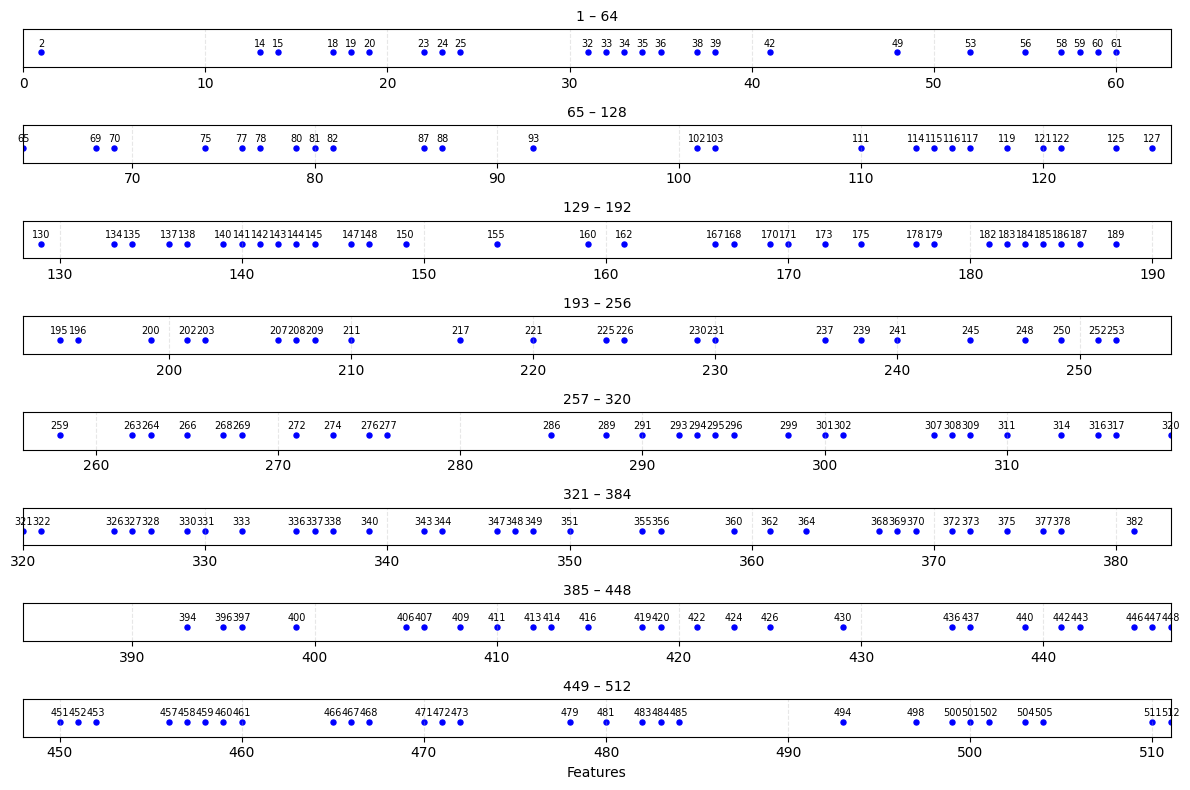

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Index các feature được chọn
selected_indices = np.where(best_individual == 1)[0]
n_features = len(best_individual)

# Chia thành 8 khoảng
segments = np.array_split(np.arange(n_features), 8)

fig, axes = plt.subplots(8, 1, figsize=(12, 8), sharey=True)

for i, seg in enumerate(segments):
    ax = axes[i]

    # Feature trong khoảng
    seg_selected = selected_indices[
        (selected_indices >= seg[0]) & (selected_indices <= seg[-1])
    ]

    # Vẽ điểm
    ax.scatter(seg_selected, np.ones_like(seg_selected), color='blue', s=13)

    # Label đơn giản
    for idx in seg_selected:
        ax.text(idx, 1.02, str(idx+1), fontsize=7, ha='center')

    # Trục
    ax.set_xlim(seg[0], seg[-1])
    ax.set_ylim(0.95, 1.08)
    ax.set_yticks([])
    ax.set_title(f"{seg[0]+1} – {seg[-1]+1}", fontsize=10)

    ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.xlabel("Features")
plt.tight_layout()
plt.savefig("Selectedfeatures8.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
data = np.load('/kaggle/input/datafeaturesnew/features_MRIbrain.npz')
features_train = data['features_train']
features_test  = data['features_test']
y_train = data['y_train']
y_test  = data['y_test']

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
st = time.time()
# --------- Chọn feature theo GA ---------
X_train_selected = features_train[:, best_individual]
X_test_selected  = features_test[:, best_individual]

# --------- Huấn luyện XGBoost ---------
clf = XGBClassifier(use_label_encoder=False,objective='multi:softprob',
                    eval_metric='mlogloss',
                    verbosity=0,
                    random_state=0)

clf.fit(
    X_train_selected, y_train,
    eval_set=[(X_train_selected, y_train), (X_test_selected, y_test)],
    verbose=False
)

# Lấy logloss theo từng epoch
evals_result = clf.evals_result()

# --------- Dự đoán ---------
y_pred = clf.predict(X_test_selected)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy using selected features (XGBoost): {test_accuracy:.4f}")

# --------- Plot mlogloss ---------
epochs = len(evals_result['validation_0']['mlogloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(7,5))
plt.plot(x_axis, evals_result['validation_0']['mlogloss'], label='Train')
plt.plot(x_axis, evals_result['validation_1']['mlogloss'], label='Test')
plt.xlabel('Epochs')
plt.ylabel('Log Loss (mlogloss)')
plt.title('XGBoost Log Loss over Epochs')
plt.legend()
plt.grid(True)
plt.savefig("XGBoost_mlogloss.png")
plt.show()

# --------- Confusion Matrix ---------
cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (XGBoost with GA features)")
plt.savefig("CM_MRIEX2.png")
plt.show()

# --------- Classification Report ---------
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
end = time.time()
print("Total Time:", end - st)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

st = time.time()

# =========================
# 1) Chọn feature theo GA
# =========================
X_train_selected = features_train[:, best_individual]
X_test_selected  = features_test[:, best_individual]

# =========================
# 2) Tách validation từ train
# =========================
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_selected, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

# =========================
# 3) Base model chạy bằng GPU
# =========================
base_model = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    tree_method='hist',
    device='cuda',          # bật GPU
    random_state=42,
    n_jobs=1,               # tránh oversubscribe CPU khi đã dùng GPU
    verbosity=0
)

# =========================
# 4) Không gian tham số
# =========================
param_dist = {
    'n_estimators': [200, 300, 500, 800, 1000],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5, 1],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 2, 5, 10]
}

# =========================
# 5) Cross-validation
#    n_splits phải >= 2
# =========================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=40,
    scoring='accuracy',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=1,      # rất quan trọng khi chỉ có 1 GPU
    refit=True
)

search.fit(X_tr, y_tr)

print("Best CV score:", search.best_score_)
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

# =========================
# 6) Fit lại model tốt nhất với early stopping
# =========================
best_params = search.best_params_

clf = XGBClassifier(
    **best_params,
    objective='multi:softprob',
    eval_metric='mlogloss',
    tree_method='hist',
    device='cuda',
    random_state=42,
    n_jobs=1,
    verbosity=0,
    early_stopping_rounds=30
)

clf.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=False
)

evals_result = clf.evals_result()

# =========================
# 7) Dự đoán trên test set
# =========================
y_pred = clf.predict(X_test_selected)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"\nTest accuracy using selected features (Tuned XGBoost - GPU): {test_accuracy:.4f}")

# =========================
# 8) Plot mlogloss
# =========================
epochs = len(evals_result['validation_0']['mlogloss'])
x_axis = range(epochs)

plt.figure(figsize=(7, 5))
plt.plot(x_axis, evals_result['validation_0']['mlogloss'], label='Train')
plt.plot(x_axis, evals_result['validation_1']['mlogloss'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Log Loss (mlogloss)')
plt.title('Tuned XGBoost Log Loss over Epochs')
plt.legend()
plt.grid(True)
plt.savefig("XGBoost_tuned_mlogloss.png", dpi=300, bbox_inches='tight')
plt.show()

# =========================
# 9) Confusion Matrix
# =========================
cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Tuned XGBoost with GA features)")
plt.savefig("CM_XGBoost_Tuned.png", dpi=300, bbox_inches='tight')
plt.show()

# =========================
# 10) Classification Report
# =========================
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
end = time.time()
print("Total Time:", end - st)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random
import os
from tensorflow.keras.utils import load_img
from tensorflow.keras.utils import img_to_array

# --- Chọn 10 ảnh ngẫu nhiên từ test set ---
idxs = random.sample(range(len(y_test)), 10)

sample_images = []   # ảnh gốc để hiển thị
sample_features = [] # đặc trưng đã chọn (cho XGBoost)
sample_labels = []   # nhãn thật

BASE_DIR = "/kaggle/input/datamri"
train_dir = os.path.join(BASE_DIR, "Training")
test_dir  = os.path.join(BASE_DIR, "Testing")

# Lấy class names từ thư mục
categories = sorted(os.listdir(train_dir))
print("Categories:", categories)

for i in idxs:
    # Tạo đường dẫn ảnh
    class_name = categories[y_test[i]]
    class_folder = os.path.join(test_dir, class_name)
    # lấy file bất kỳ trong folder (hoặc nếu có list test_paths thì dùng trực tiếp)
    img_files = os.listdir(class_folder)
    img_path = os.path.join(class_folder, random.choice(img_files))

    # Load ảnh bằng keras
    img = load_img(img_path, target_size=(224, 224))
    sample_images.append(img)

    # Thêm feature và label
    sample_features.append(features_test[i, best_individual])
    sample_labels.append(y_test[i])

sample_features = np.array(sample_features)
sample_labels = np.array(sample_labels)

# --- Dự đoán bằng XGBoost ---
preds = clf.predict(sample_features)
pred_probs = clf.predict_proba(sample_features).max(axis=1) * 100

# --- Hiển thị kết quả ---
plt.figure(figsize=(18, 8))
for j in range(len(sample_images)):
    plt.subplot(2, 5, j+1)
    plt.imshow(sample_images[j])   # ảnh gốc
    plt.axis("off")

    true_label = categories[sample_labels[j]]
    pred_label = categories[preds[j]]
    prob = pred_probs[j]

    plt.title(f"Pred: {pred_label}\n({prob:.1f}%)\nTrue: {true_label}", fontsize=9)

plt.tight_layout()
plt.savefig("testrandom10MRI.png")
plt.show()


# VGG16+GA+Random Forest

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

st = time.time()

# --------- Chọn feature theo GA ---------
X_train_selected = features_train[:, best_individual]
X_test_selected  = features_test[:, best_individual]

# --------- Huấn luyện Random Forest ---------
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train_selected, y_train)

# --------- Dự đoán ---------
y_pred = clf.predict(X_test_selected)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test accuracy using selected features (Random Forest): {test_accuracy:.4f}")

# --------- Confusion Matrix ---------
cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Random Forest with GA features)")
plt.savefig("CM_RF.png")
plt.show()

# --------- Classification Report ---------
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

end = time.time()
print("Total Time:", end - st)

# VGG16+GA+SVM

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

st = time.time()

# --------- Chọn feature theo GA ---------
X_train_selected = features_train[:, best_individual]
X_test_selected  = features_test[:, best_individual]

# --------- Huấn luyện SVM ---------
# SVM rất nhạy với scale => nên dùng StandardScaler
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",        # rbf thường mạnh
        C=10.0,              # bạn có thể tune
        gamma="scale",       # mặc định ổn
        probability=False,   # True nếu cần predict_proba (chậm hơn)
        random_state=42
    ))
])

clf.fit(X_train_selected, y_train)

# --------- Dự đoán ---------
y_pred = clf.predict(X_test_selected)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy using selected features (SVM): {test_accuracy:.4f}")

# --------- Confusion Matrix ---------
cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (SVM with GA features)")
plt.savefig("CM_SVM.png")
plt.show()

# --------- Classification Report ---------
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

end = time.time()
print("Total Time:", end - st)

# Decision Tree

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

st = time.time()

# --------- Chọn feature theo GA ---------
X_train_selected = features_train[:, best_individual]
X_test_selected  = features_test[:, best_individual]

# --------- Huấn luyện Decision Tree ---------
clf = DecisionTreeClassifier(
    criterion="gini",      # hoặc "entropy", "log_loss" (tuỳ sklearn version)
    max_depth=None,        # set số cụ thể để giảm overfitting (vd: 5, 10, 20)
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

clf.fit(X_train_selected, y_train)

# --------- Dự đoán ---------
y_pred = clf.predict(X_test_selected)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy using selected features (Decision Tree): {test_accuracy:.4f}")

# --------- Confusion Matrix ---------
cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Decision Tree with GA features)")
plt.savefig("CM_DT.png")
plt.show()

# --------- Classification Report ---------
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

end = time.time()
print("Total Time:", end - st)

# Naive Bayes

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

st = time.time()

# --------- Chọn feature theo GA ---------
X_train_selected = features_train[:, best_individual]
X_test_selected  = features_test[:, best_individual]

# --------- Huấn luyện Naive Bayes (Gaussian) ---------
clf = GaussianNB()
clf.fit(X_train_selected, y_train)

# --------- Dự đoán ---------
y_pred = clf.predict(X_test_selected)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy using selected features (GaussianNB): {test_accuracy:.4f}")

# --------- Confusion Matrix ---------
cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (GaussianNB with GA features)")
plt.savefig("CM_GNB.png")
plt.show()

# --------- Classification Report ---------
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

end = time.time()
print("Total Time:", end - st)

# Adaboost

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

st = time.time()

# --------- Chọn feature theo GA ---------
X_train_selected = features_train[:, best_individual]
X_test_selected  = features_test[:, best_individual]

# --------- Huấn luyện AdaBoost ---------
# Base learner thường dùng DecisionTree stump (max_depth=1)
base_est = DecisionTreeClassifier(max_depth=1, random_state=42)

clf = AdaBoostClassifier(
    estimator=base_est,     # nếu sklearn cũ dùng base_estimator=
    n_estimators=300,
    learning_rate=0.5,
    algorithm="SAMME.R",    # nếu lỗi version thì đổi sang "SAMME"
    random_state=42
)

clf.fit(X_train_selected, y_train)

# --------- Dự đoán ---------
y_pred = clf.predict(X_test_selected)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy using selected features (AdaBoost): {test_accuracy:.4f}")

# --------- Plot error theo số estimator (giống 'epoch') ---------
train_err = []
test_err = []

for yhat_tr in clf.staged_predict(X_train_selected):
    train_err.append(1 - accuracy_score(y_train, yhat_tr))

for yhat_te in clf.staged_predict(X_test_selected):
    test_err.append(1 - accuracy_score(y_test, yhat_te))

x_axis = range(1, len(train_err) + 1)

plt.figure(figsize=(7,5))
plt.plot(x_axis, train_err, label="Train error")
plt.plot(x_axis, test_err, label="Test error")
plt.xlabel("Number of Estimators")
plt.ylabel("Error (1 - accuracy)")
plt.title("AdaBoost Error over Number of Estimators")
plt.legend()
plt.grid(True)
plt.savefig("AdaBoost_error.png")
plt.show()

# --------- Confusion Matrix ---------
cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (AdaBoost with GA features)")
plt.savefig("CM_AdaBoost.png")
plt.show()

# --------- Classification Report ---------
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

end = time.time()
print("Total Time:", end - st)

# ANN

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

st = time.time()

# --------- Chọn feature theo GA ---------
X_train_selected = features_train[:, best_individual]
X_test_selected  = features_test[:, best_individual]

# --------- Huấn luyện ANN (MLP) ---------
# early_stopping=True sẽ tự tách 1 phần train làm validation và dừng sớm khi không cải thiện
clf = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(256, 128),   # bạn có thể đổi (128,), (256,128,64)...
        activation="relu",
        solver="adam",
        alpha=1e-4,                      # L2 regularization
        batch_size=128,
        learning_rate_init=1e-3,
        max_iter=200,                    # số epoch tối đa
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        random_state=42,
        verbose=False
    ))
])

clf.fit(X_train_selected, y_train)

# --------- Dự đoán ---------
y_pred = clf.predict(X_test_selected)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy using selected features (ANN-MLP): {test_accuracy:.4f}")

# --------- Plot loss curve (epoch) ---------
mlp = clf.named_steps["mlp"]
loss_curve = getattr(mlp, "loss_curve_", None)

if loss_curve is not None and len(loss_curve) > 0:
    x_axis = range(1, len(loss_curve) + 1)
    plt.figure(figsize=(7,5))
    plt.plot(x_axis, loss_curve, label="Train loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("ANN (MLP) Training Loss over Epochs")
    plt.grid(True)
    plt.legend()
    plt.savefig("ANN_loss.png")
    plt.show()
else:
    print("No loss_curve_ found (sklearn version/config).")

# --------- Confusion Matrix ---------
cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (ANN-MLP with GA features)")
plt.savefig("CM_ANN.png")
plt.show()

# --------- Classification Report ---------
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

end = time.time()
print("Total Time:", end - st)

In [ ]:
import numpy as np
import pandas as pd
import time

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# =========================
# 0) Chuẩn bị dữ liệu (ĐÚNG với input của bạn)
# =========================
# Bạn đã có: features_train, y_train, features_test, y_test, best_individual

X_all = features_train
y_all = y_train

# --- Chuẩn hóa best_individual thành mask boolean ---
best_individual = np.array(best_individual)

# Nếu GA trả về index list (vd [1,5,9...]) thì convert sang mask bool
if best_individual.dtype != bool:
    # trường hợp dạng 0/1 vector
    if best_individual.ndim == 1 and best_individual.size == X_all.shape[1] and np.isin(best_individual, [0, 1]).all():
        mask = best_individual.astype(bool)
    # trường hợp là danh sách index
    else:
        mask = np.zeros(X_all.shape[1], dtype=bool)
        mask[best_individual.astype(int)] = True
else:
    mask = best_individual

# check kích thước mask
if mask.shape[0] != X_all.shape[1]:
    raise ValueError(f"Mask length {mask.shape[0]} != number of features {X_all.shape[1]}")

# Áp mask GA
X_selected = X_all[:, mask]

print("Total features:", X_all.shape[1])
print("Selected features:", int(mask.sum()))


# 5-fold Stratified
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# =========================
# 1) Khai báo mô hình
# =========================
models = {
    "XGBoost": XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    eval_metric="mlogloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1
    ),

    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=10.0, gamma="scale", random_state=42))
    ]),

    "Naive Bayes (Gaussian)": GaussianNB(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    # Nếu sklearn cũ: đổi estimator= thành base_estimator=
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=300,
        learning_rate=0.5,
        random_state=42
    ),

    "ANN (MLP)": Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(
            hidden_layer_sizes=(256, 128),
            activation="relu",
            solver="adam",
            alpha=1e-4,
            batch_size=128,
            learning_rate_init=1e-3,
            max_iter=200,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=15,
            random_state=42
        ))
    ])
}


# =========================
# 2) Chạy CV và tính metrics
# =========================
def eval_model_cv(model, X, y, cv):
    accs, precs, recs, f1s, times = [], [], [], [], []

    for train_idx, val_idx in cv.split(X, y):
        Xtr, Xva = X[train_idx], X[val_idx]
        ytr, yva = y[train_idx], y[val_idx]

        t0 = time.time()
        model.fit(Xtr, ytr)
        ypred = model.predict(Xva)
        t1 = time.time()

        accs.append(accuracy_score(yva, ypred))
        precs.append(precision_score(yva, ypred, average="macro", zero_division=0))
        recs.append(recall_score(yva, ypred, average="macro", zero_division=0))
        f1s.append(f1_score(yva, ypred, average="macro", zero_division=0))
        times.append(t1 - t0)

    return {
        "ACC_mean": float(np.mean(accs)), "ACC_std": float(np.std(accs)),
        "Precision_mean": float(np.mean(precs)), "Precision_std": float(np.std(precs)),
        "Recall_mean": float(np.mean(recs)), "Recall_std": float(np.std(recs)),
        "F1_mean": float(np.mean(f1s)), "F1_std": float(np.std(f1s)),
        "Time_mean_s": float(np.mean(times)), "Time_std_s": float(np.std(times)),
        "Time_total_s": float(np.sum(times))
    }

results = []
for name, model in models.items():
    out = eval_model_cv(model, X_selected, y_all, skf)
    out["Method"] = name
    results.append(out)

df = pd.DataFrame(results).set_index("Method")


# =========================
# 3) In bảng mean ± std
# =========================
def mean_std_str(mean, std, nd=4):
    return f"{mean:.{nd}f} ± {std:.{nd}f}"

df_pretty = pd.DataFrame(index=df.index)
df_pretty["ACC"] = [mean_std_str(df.loc[m, "ACC_mean"], df.loc[m, "ACC_std"], 4) for m in df.index]
df_pretty["Precision (macro)"] = [mean_std_str(df.loc[m, "Precision_mean"], df.loc[m, "Precision_std"], 4) for m in df.index]
df_pretty["Recall (macro)"] = [mean_std_str(df.loc[m, "Recall_mean"], df.loc[m, "Recall_std"], 4) for m in df.index]
df_pretty["F1 (macro)"] = [mean_std_str(df.loc[m, "F1_mean"], df.loc[m, "F1_std"], 4) for m in df.index]
df_pretty["Time/fold (s)"] = [mean_std_str(df.loc[m, "Time_mean_s"], df.loc[m, "Time_std_s"], 2) for m in df.index]
df_pretty["Time total (s)"] = df["Time_total_s"].round(2)

print(df_pretty.sort_values("F1 (macro)", ascending=False))

# So sánh với các thuật toán học sâu

In [ ]:
import os
import tensorflow as tf
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

BASE_DIR = "/kaggle/input/datamri"
train_dir = os.path.join(BASE_DIR, "Training")
test_dir  = os.path.join(BASE_DIR, "Testing")

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)

# Get class names from the dataset
class_names = train_ds.class_names
num_classes = len(class_names)

# Data Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Define K-Fold Cross-validation
kfold = KFold(n_splits=5, shuffle=True)

# VGG16 Model Building
def create_vgg16_model():
    base_model = tf.keras.applications.VGG16(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # Freeze the base model

    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Parallel Training
strategy = tf.distribute.MirroredStrategy()

# Training the model with K-Fold Cross-validation
fold_no = 1
for train_index, val_index in kfold.split(np.arange(len(train_ds))):
    print(f"\nTraining fold {fold_no}...")

    # Get training and validation subsets
    train_subset = train_ds.take(len(train_index))
    val_subset = train_ds.skip(len(train_index)).take(len(val_index))
    
    with strategy.scope():
        model = create_vgg16_model()
        
        model.fit(
            train_subset,
            validation_data=val_subset,
            epochs=2,
            batch_size=BATCH_SIZE,
        )

    fold_no += 1

# Evaluate on the test dataset after K-folds
model = create_vgg16_model()
model.fit(train_ds, epochs=2, batch_size=BATCH_SIZE)
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc}")

# Mo ta layer VGG16

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model

# ========================
# 1. Paths
# ========================
BASE_DIR = "/kaggle/input/datamri"

train_dir = os.path.join(BASE_DIR, "Training")
test_dir  = os.path.join(BASE_DIR, "Testing")

print("Train path:", train_dir)
print("Test path:", test_dir)

# ========================
# 2. Parameters
# ========================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# ========================
# 3. Load raw datasets
# ========================
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

# Lưu class names từ dataset gốc
class_names = train_ds_raw.class_names
num_classes = len(class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)

# ========================
# 4. Optimize datasets
# ========================
train_ds = train_ds_raw.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds_raw.cache().prefetch(buffer_size=AUTOTUNE)

# ========================
# 5. Optional augmentation
# ========================
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# ========================
# 6. Load VGG16 pretrained
# ========================
base_model = VGG16(weights="imagenet", include_top=False)

layer_names = [
    "block1_conv2",   # conv1
    "block2_conv2",   # conv2
    "block3_conv3",   # conv3
    "block4_conv3",   # conv4
    "block5_conv3"    # conv5
]

layer_outputs = [base_model.get_layer(name).output for name in layer_names]
feature_extractor = Model(inputs=base_model.input, outputs=layer_outputs)

print("\nSelected VGG16 layers:")
for name in layer_names:
    print("-", name)

# ========================
# 7. Get 1 image for each class
# ========================
def get_one_image_per_class(dataset, class_names):
    num_classes = len(class_names)

    class_images = [None] * num_classes
    class_labels = [None] * num_classes
    found = [False] * num_classes

    for images, labels in dataset:
        images_np = images.numpy()
        labels_np = labels.numpy()

        for i in range(images_np.shape[0]):
            label_idx = np.argmax(labels_np[i])

            if not found[label_idx]:
                class_images[label_idx] = images_np[i]
                class_labels[label_idx] = label_idx
                found[label_idx] = True
                print(f"Collected 1 image for class: {class_names[label_idx]}")

            if all(found):
                break

        if all(found):
            break

    if not all(found):
        missing = [class_names[i] for i, ok in enumerate(found) if not ok]
        raise ValueError(f"Không tìm đủ ảnh cho các class: {missing}")

    sample_images = np.stack(class_images, axis=0)
    sample_labels = np.array(class_labels)

    return sample_images, sample_labels

sample_images, sample_labels = get_one_image_per_class(train_ds, class_names)

print("\nCollected sample images shape:", sample_images.shape)
print("Collected sample labels:", sample_labels)

# ========================
# 8. Show original images
# ========================
plt.figure(figsize=(16, 4))
for i in range(num_classes):
    plt.subplot(1, num_classes, i + 1)
    plt.imshow(sample_images[i].astype("uint8"))
    plt.title(class_names[sample_labels[i]], fontsize=12)
    plt.axis("off")
plt.suptitle("One image for each class", fontsize=14)
plt.tight_layout()
plt.show()

# ========================
# 9. Preprocess for VGG16
# ========================
vgg_input = preprocess_input(sample_images.copy())

# ========================
# 10. Extract feature maps
# ========================
feature_maps_list = feature_extractor.predict(vgg_input, verbose=1)

print("\nFeature map shapes:")
for name, fmap in zip(layer_names, feature_maps_list):
    print(f"{name}: {fmap.shape}")

# ========================
# 11. Function: plot feature maps for one image
# ========================
def plot_feature_maps_for_one_image(feature_maps_list, image_index, layer_names, class_names, max_filters=8):
    for layer_idx, fmap in enumerate(feature_maps_list):
        n_filters = min(max_filters, fmap.shape[-1])

        plt.figure(figsize=(2 * n_filters, 2.5))
        plt.suptitle(
            f"Class: {class_names[image_index]} | Layer: {layer_names[layer_idx]}",
            fontsize=14
        )

        for j in range(n_filters):
            plt.subplot(1, n_filters, j + 1)
            plt.imshow(fmap[image_index, :, :, j], cmap="viridis")
            plt.axis("off")
            plt.title(f"F{j+1}", fontsize=8)

        plt.tight_layout()
        plt.show()

# ========================
# 12. Show detailed feature maps
# ========================
for img_idx in range(num_classes):
    plot_feature_maps_for_one_image(
        feature_maps_list=feature_maps_list,
        image_index=img_idx,
        layer_names=layer_names,
        class_names=class_names,
        max_filters=8
    )

# ========================
# 13. Compact summary plot
#     4 rows x 5 cols
#     each cell = first filter of each layer
# ========================
fig, axes = plt.subplots(num_classes, len(layer_names), figsize=(18, 12))

for i in range(num_classes):
    for j in range(len(layer_names)):
        fmap = feature_maps_list[j]
        axes[i, j].imshow(fmap[i, :, :, 0], cmap="viridis")
        axes[i, j].axis("off")

        if i == 0:
            axes[i, j].set_title(layer_names[j], fontsize=11)

        if j == 0:
            axes[i, j].set_ylabel(class_names[i], fontsize=11)

plt.suptitle("VGG16 Feature Maps Summary (first filter only)", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
SAVE_DIR = "/kaggle/working/vgg16_outputs"
os.makedirs(SAVE_DIR, exist_ok=True)

In [ ]:
for i, class_name in enumerate(class_names):
    plt.figure()
    plt.imshow(sample_images[i].astype("uint8"))
    plt.axis("off")
    
    save_path = os.path.join(SAVE_DIR, f"{class_name}_original.png")
    plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
    plt.close()
    
    print("Saved:", save_path)

In [ ]:
def save_feature_maps(feature_maps_list, class_names, layer_names, save_dir, max_filters=16):
    for i, class_name in enumerate(class_names):
        for layer_idx, fmap in enumerate(feature_maps_list):
            layer_name = layer_names[layer_idx]
            
            n_filters = min(max_filters, fmap.shape[-1])
            
            cols = 4
            rows = int(np.ceil(n_filters / cols))
            
            plt.figure(figsize=(cols * 2, rows * 2))
            
            for j in range(n_filters):
                plt.subplot(rows, cols, j + 1)
                plt.imshow(fmap[i, :, :, j], cmap="viridis")
                plt.axis("off")
            
            plt.suptitle(f"{class_name} - {layer_name}", fontsize=12)
            
            save_path = os.path.join(
                save_dir,
                f"{class_name}_{layer_name}.png"
            )
            
            plt.savefig(save_path, bbox_inches="tight")
            plt.close()
            
            print("Saved:", save_path)

# chạy
save_feature_maps(
    feature_maps_list=feature_maps_list,
    class_names=class_names,
    layer_names=layer_names,
    save_dir=SAVE_DIR,
    max_filters=16
)

In [ ]:
# ========================
# 8. Show gọn: mỗi ảnh 1 hàng, mỗi layer 1 cột
#    mỗi ô chỉ hiện filter đầu tiên
# ========================
fig, axes = plt.subplots(3, 5, figsize=(18, 10))

for img_idx in range(3):
    for layer_idx, fmap in enumerate(feature_maps_list):
        axes[img_idx, layer_idx].imshow(fmap[img_idx, :, :, 0], cmap="viridis")
        axes[img_idx, layer_idx].axis("off")
        axes[img_idx, layer_idx].set_title(f"Img {img_idx+1}\n{layer_names[layer_idx]}")

plt.tight_layout()
plt.show()